# Solution 2: Deep Learning Model for 30-Day Readmission Prediction

This notebook builds on the preprocessing done in solution_1.ipynb.
- Uses **train_df.csv** (already partially preprocessed) and **test_df.csv**
- Completes remaining preprocessing (encoding, imputation, scaling)
- Handles severe class imbalance (~9% positive)
- Trains a PyTorch deep neural network
- Evaluates with AUC-ROC, AUC-PR, F1, Recall, Precision

## 1. Imports & Setup

In [21]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, f1_score, precision_recall_curve,
    roc_curve, precision_score, recall_score
)

# Imbalanced learn
from imblearn.over_sampling import SMOTE

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Settings
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print('All imports successful!')

All imports successful!


## 2. Load Preprocessed Data

Loading the files produced by solution_1.ipynb:
- **train_df.csv**: patient_id dropped, admission_date → month/day/weekday, glucose_missing indicator added
- **test_df.csv**: still has admission_date (needs same feature engineering)

In [22]:
# Load preprocessed datasets
train_df = pd.read_csv('train_df.csv', index_col=0)
test_df = pd.read_csv('test_df.csv', index_col=0)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
print(f'\nTrain columns ({len(train_df.columns)}):\n{list(train_df.columns)}')
print(f'\nTest columns ({len(test_df.columns)}):\n{list(test_df.columns)}')
print(f'\nTrain dtypes:\n{train_df.dtypes}')
print(f'\nMissing values (train):\n{train_df.isnull().sum()}')
print(f'\nMissing values (test):\n{test_df.isnull().sum()}')

Train shape: (3800, 20)
Test shape:  (950, 16)

Train columns (20):
['age', 'gender', 'admission_type', 'discharge_destination', 'discharge_day_of_week', 'length_of_stay_days', 'charlson_comorbidity_index', 'prior_admissions_1yr', 'n_medications_discharge', 'insurance_type', 'glucose_level_mgdl', 'blood_pressure_systolic', 'sodium_meql', 'creatinine_mgdl', 'haemoglobin_gdl', 'readmitted_30d', 'admission_month', 'admission_day', 'admission_weekday', 'glucose_missing']

Test columns (16):
['admission_date', 'age', 'gender', 'admission_type', 'discharge_destination', 'discharge_day_of_week', 'length_of_stay_days', 'charlson_comorbidity_index', 'prior_admissions_1yr', 'n_medications_discharge', 'insurance_type', 'glucose_level_mgdl', 'blood_pressure_systolic', 'sodium_meql', 'creatinine_mgdl', 'haemoglobin_gdl']

Train dtypes:
age                           float64
gender                            str
admission_type                  int64
discharge_destination           int64
discharge_day

In [23]:
display(train_df.head())
display(test_df.head())

,age,gender,admission_type,discharge_destination,discharge_day_of_week,length_of_stay_days,charlson_comorbidity_index,prior_admissions_1yr,n_medications_discharge,insurance_type,glucose_level_mgdl,blood_pressure_systolic,sodium_meql,creatinine_mgdl,haemoglobin_gdl,readmitted_30d,admission_month,admission_day,admission_weekday,glucose_missing
0,24.0,M,1,1,Tue,1.8,7.0,6.0,2,Private,100.4,112.300000,132.5,0.82,10.3,0,1,1,2,0
1,73.0,F,1,1,Thu,14.7,2.0,2.0,14,Medicaid,114.3,166.100000,154.3,1.32,10.6,0,1,1,2,0
2,65.0,F,1,3,Wed,10.6,0.0,0.0,3,Private,106.4,132.685968,133.8,1.08,13.6,0,1,1,2,0
3,49.0,M,2,1,Fri,9.1,0.0,0.0,9,Medicaid,97.4,131.900000,149.8,0.64,13.5,0,1,1,2,0
4,49.0,F,1,1,Thu,7.5,0.0,0.0,7,Medicare,NaN,137.300000,142.4,2.26,11.9,0,2,1,5,1


,admission_date,age,gender,admission_type,discharge_destination,discharge_day_of_week,length_of_stay_days,charlson_comorbidity_index,prior_admissions_1yr,n_medications_discharge,insurance_type,glucose_level_mgdl,blood_pressure_systolic,sodium_meql,creatinine_mgdl,haemoglobin_gdl
0,2020-01-01,89.0,F,2,1,Sun,12.2,1.0,1.0,15,Medicare,64.1,120.3,138.3,1.57,10.5
1,2020-01-01,85.0,M,2,2,Thu,8.1,0.0,1.0,5,Uninsured,142.4,130.4,138.5,1.03,11.1
2,01/01/2020,55.0,F,1,3,Wed,1.7,2.0,1.0,12,Medicaid,109.9,130.8,142.8,1.30,11.1
3,2020-01-01,66.0,F,1,1,Sun,20.5,2.0,2.0,7,Medicare,136.5,102.4,138.8,1.21,13.7
4,02/01/2020,70.0,M,1,3,Wed,4.4,1.0,0.0,17,Medicare,60.0,140.8,130.6,0.71,14.1


## 3. Class Imbalance Analysis

Target Distribution:
readmitted_30d
0    3458
1     342
Name: count, dtype: int64

Positive class ratio: 0.0900 (9.0%)
Imbalance ratio: 10.1:1


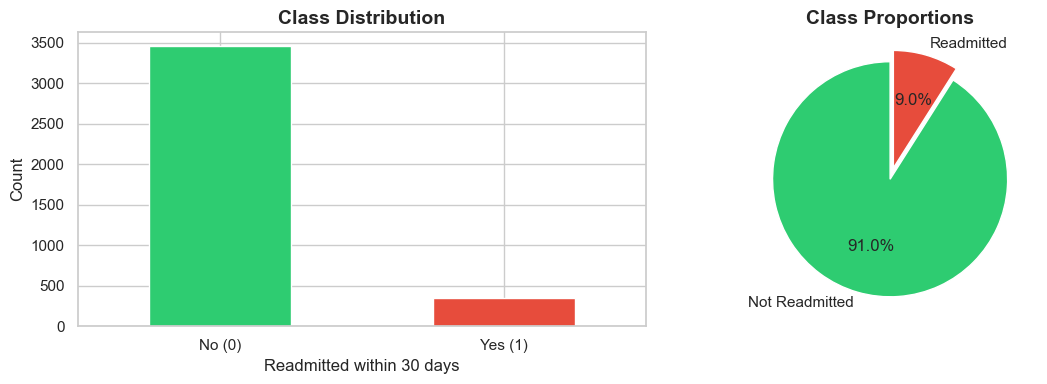


⚠️  SEVERE CLASS IMBALANCE: Only ~9.0% of patients are readmitted.
Mitigation: SMOTE + class-weighted loss + threshold tuning.


In [24]:
# Target distribution
target_counts = train_df['readmitted_30d'].value_counts()
target_ratio = train_df['readmitted_30d'].mean()

print('Target Distribution:')
print(target_counts)
print(f'\nPositive class ratio: {target_ratio:.4f} ({target_ratio*100:.1f}%)')
print(f'Imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Readmitted within 30 days')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)

axes[1].pie(target_counts, labels=['Not Readmitted', 'Readmitted'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n⚠️  SEVERE CLASS IMBALANCE: Only ~{target_ratio*100:.1f}% of patients are readmitted.')
print('Mitigation: SMOTE + class-weighted loss + threshold tuning.')

## 4. Complete Remaining Preprocessing

train_df.csv already has:
- `patient_id` dropped
- `admission_date` → `admission_month`, `admission_day`, `admission_weekday`
- `glucose_missing` indicator
- Age outliers (999) replaced with NaN

Still needed (for both train and test):
1. Apply same date engineering to test set
2. Impute remaining NaNs (age, glucose)
3. Encode string categoricals (gender, insurance_type, discharge_day_of_week)
4. StandardScaler on numeric features

In [25]:
# ---- Step 4a: Bring test_df to same feature state as train_df ----

# test_df still has admission_date - extract features then drop
if 'admission_date' in test_df.columns:
    test_df['admission_date'] = pd.to_datetime(
        test_df['admission_date'], format='mixed', dayfirst=True, errors='coerce'
    )
    test_df['admission_month'] = test_df['admission_date'].dt.month
    test_df['admission_day'] = test_df['admission_date'].dt.day
    test_df['admission_weekday'] = test_df['admission_date'].dt.weekday
    test_df = test_df.drop(columns=['admission_date'])
    print('✅ test_df: admission_date → month/day/weekday, then dropped.')

# Create glucose_missing indicator for test (same as done for train in solution_1)
if 'glucose_missing' not in test_df.columns:
    test_df['glucose_missing'] = test_df['glucose_level_mgdl'].isnull().astype(int)
    print('✅ test_df: glucose_missing indicator created.')

print(f'\nTrain columns: {sorted(train_df.columns)}')
print(f'Test columns:  {sorted(test_df.columns)}')

✅ test_df: admission_date → month/day/weekday, then dropped.
✅ test_df: glucose_missing indicator created.

Train columns: ['admission_day', 'admission_month', 'admission_type', 'admission_weekday', 'age', 'blood_pressure_systolic', 'charlson_comorbidity_index', 'creatinine_mgdl', 'discharge_day_of_week', 'discharge_destination', 'gender', 'glucose_level_mgdl', 'glucose_missing', 'haemoglobin_gdl', 'insurance_type', 'length_of_stay_days', 'n_medications_discharge', 'prior_admissions_1yr', 'readmitted_30d', 'sodium_meql']
Test columns:  ['admission_day', 'admission_month', 'admission_type', 'admission_weekday', 'age', 'blood_pressure_systolic', 'charlson_comorbidity_index', 'creatinine_mgdl', 'discharge_day_of_week', 'discharge_destination', 'gender', 'glucose_level_mgdl', 'glucose_missing', 'haemoglobin_gdl', 'insurance_type', 'length_of_stay_days', 'n_medications_discharge', 'prior_admissions_1yr', 'sodium_meql']


In [26]:
# ---- Step 4b: Impute missing values ----
# Use TRAIN medians to fill both train and test (prevent data leakage)

age_median = train_df['age'].median()
glucose_median = train_df['glucose_level_mgdl'].median()

print(f'Imputation values (from train):')
print(f'  age median:     {age_median}')
print(f'  glucose median: {glucose_median}')

# Train
train_df['age'] = train_df['age'].fillna(age_median)
train_df['glucose_level_mgdl'] = train_df['glucose_level_mgdl'].fillna(glucose_median)

# Test
test_df['age'] = test_df['age'].fillna(age_median)
test_df['glucose_level_mgdl'] = test_df['glucose_level_mgdl'].fillna(glucose_median)

print(f'\nRemaining NaNs in train: {train_df.isnull().sum().sum()}')
print(f'Remaining NaNs in test:  {test_df.isnull().sum().sum()}')

Imputation values (from train):
  age median:     53.0
  glucose median: 103.6

Remaining NaNs in train: 0
Remaining NaNs in test:  0


In [27]:
# ---- Step 4c: Encode categorical string columns ----

# 1. gender: M=1, F=0
train_df['gender'] = (train_df['gender'] == 'M').astype(int)
test_df['gender'] = (test_df['gender'] == 'M').astype(int)
print('✅ gender encoded (M=1, F=0)')

# 2. insurance_type: one-hot encode
train_insurance = pd.get_dummies(train_df['insurance_type'], prefix='ins')
test_insurance = pd.get_dummies(test_df['insurance_type'], prefix='ins')

# Align columns (test might be missing a category)
for col in train_insurance.columns:
    if col not in test_insurance.columns:
        test_insurance[col] = 0
test_insurance = test_insurance[train_insurance.columns]

train_df = pd.concat([train_df.drop(columns=['insurance_type']), train_insurance], axis=1)
test_df = pd.concat([test_df.drop(columns=['insurance_type']), test_insurance], axis=1)
print(f'✅ insurance_type one-hot encoded: {list(train_insurance.columns)}')

# 3. discharge_day_of_week: one-hot encode
train_day = pd.get_dummies(train_df['discharge_day_of_week'], prefix='day')
test_day = pd.get_dummies(test_df['discharge_day_of_week'], prefix='day')

for col in train_day.columns:
    if col not in test_day.columns:
        test_day[col] = 0
test_day = test_day[train_day.columns]

train_df = pd.concat([train_df.drop(columns=['discharge_day_of_week']), train_day], axis=1)
test_df = pd.concat([test_df.drop(columns=['discharge_day_of_week']), test_day], axis=1)
print(f'✅ discharge_day_of_week one-hot encoded: {list(train_day.columns)}')

print(f'\nFinal train shape: {train_df.shape}')
print(f'Final test shape:  {test_df.shape}')

✅ gender encoded (M=1, F=0)
✅ insurance_type one-hot encoded: ['ins_Medicaid', 'ins_Medicare', 'ins_Private', 'ins_Uninsured']
✅ discharge_day_of_week one-hot encoded: ['day_Fri', 'day_Mon', 'day_Sat', 'day_Sun', 'day_Thu', 'day_Tue', 'day_Wed']

Final train shape: (3800, 29)
Final test shape:  (950, 28)


## Step 4d: Separate features and target, then scale

In [28]:


TARGET = 'readmitted_30d'

y_full = train_df[TARGET].values
X_full_df = train_df.drop(columns=[TARGET])
X_test_df = test_df.copy()

# Ensure column alignment
for col in X_full_df.columns:
    if col not in X_test_df.columns:
        X_test_df[col] = 0
X_test_df = X_test_df[X_full_df.columns]

# Scale numeric features (fit on train, transform both)
numeric_cols = [
    'age', 'admission_type', 'discharge_destination',
    'length_of_stay_days', 'charlson_comorbidity_index',
    'prior_admissions_1yr', 'n_medications_discharge',
    'glucose_level_mgdl', 'blood_pressure_systolic',
    'sodium_meql', 'creatinine_mgdl', 'haemoglobin_gdl',
    'admission_month', 'admission_day', 'admission_weekday'
]
# Only scale columns that exist
numeric_cols = [c for c in numeric_cols if c in X_full_df.columns]

scaler = StandardScaler()
X_full_df[numeric_cols] = scaler.fit_transform(X_full_df[numeric_cols])
X_test_df[numeric_cols] = scaler.transform(X_test_df[numeric_cols])

print(f'✅ StandardScaler applied to {len(numeric_cols)} numeric features')
print(f'\nFeature matrix (train): {X_full_df.shape}')
print(f'Feature matrix (test):  {X_test_df.shape}')
print(f'Target: {y_full.shape}, positive ratio: {y_full.mean():.4f}')
print(f'\nAll {len(X_full_df.columns)} features:')
for i, col in enumerate(X_full_df.columns):
    print(f'  {i+1:2d}. {col}')

✅ StandardScaler applied to 15 numeric features

Feature matrix (train): (3800, 28)
Feature matrix (test):  (950, 28)
Target: (3800,), positive ratio: 0.0900

All 28 features:
   1. age
   2. gender
   3. admission_type
   4. discharge_destination
   5. length_of_stay_days
   6. charlson_comorbidity_index
   7. prior_admissions_1yr
   8. n_medications_discharge
   9. glucose_level_mgdl
  10. blood_pressure_systolic
  11. sodium_meql
  12. creatinine_mgdl
  13. haemoglobin_gdl
  14. admission_month
  15. admission_day
  16. admission_weekday
  17. glucose_missing
  18. ins_Medicaid
  19. ins_Medicare
  20. ins_Private
  21. ins_Uninsured
  22. day_Fri
  23. day_Mon
  24. day_Sat
  25. day_Sun
  26. day_Thu
  27. day_Tue
  28. day_Wed


## 5. Train/Validation Split (Stratified)

In [29]:
X_train, X_val, y_train, y_val = train_test_split(X_full_df.values, y_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_full
)

print(f'Train: {X_train.shape[0]} samples, positive ratio: {y_train.mean():.4f}')
print(f'Val:   {X_val.shape[0]} samples, positive ratio: {y_val.mean():.4f}')

Train: 3040 samples, positive ratio: 0.0901
Val:   760 samples, positive ratio: 0.0895


## 6. Handle Class Imbalance with SMOTE

The dataset has ~9% positive class (severe imbalance).
We apply SMOTE to the training split **only** (never to validation/test).

In [30]:
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.5)  # minority → 50% of majority
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {X_train.shape[0]} samples, positive: {y_train.mean():.4f}')
print(f'After SMOTE:  {X_train_sm.shape[0]} samples, positive: {y_train_sm.mean():.4f}')
print(f'\nClass distribution after SMOTE:')
unique, counts = np.unique(y_train_sm, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {int(u)}: {c}')

Before SMOTE: 3040 samples, positive: 0.0901
After SMOTE:  4149 samples, positive: 0.3333

Class distribution after SMOTE:
  Class 0: 2766
  Class 1: 1383


## 7. Prepare PyTorch Datasets

In [31]:
X_train_t = torch.FloatTensor(X_train_sm.astype(np.float32))
y_train_t = torch.FloatTensor(y_train_sm.astype(np.float32))
X_val_t = torch.FloatTensor(X_val.astype(np.float32))
y_val_t = torch.FloatTensor(y_val.astype(np.float32))
X_test_t = torch.FloatTensor(X_test_df.values.astype(np.float32))

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)

INPUT_DIM = X_train_t.shape[1]
print(f"Input features: {INPUT_DIM}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Input features: 28
Train batches: 65, Val batches: 12


## 8. Define Model

In [32]:
class ReadmissionNet(nn.Module):
    """
    4-layer feedforward neural network with BatchNorm and Dropout.
    Input → 128 → 64 → 32 → 16 → 1 (sigmoid)
    """
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze()


model = ReadmissionNet(INPUT_DIM)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

ReadmissionNet(
  (net): Sequential(
    (0): Linear(in_features=28, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=16, bias=True)
    (13): ReLU()
    (14): Linear(in_features=16, out_features=1, bias=True)
    (15): Sigmoid()
  )
)

Total parameters: 15,041


In [35]:
import torch
print(torch.__version__)

2.11.0+cu130


## 9. Training Loop (Class-Weighted Loss + Early Stopping)

In [36]:
# Class weight for minority emphasis (even after SMOTE)
n_neg = (y_train_sm == 0).sum()
n_pos = (y_train_sm == 1).sum()
POS_WEIGHT = n_neg / n_pos
print(f'Positive class weight: {POS_WEIGHT:.2f}')

criterion = nn.BCELoss(reduction='none')  # per-sample for weighting
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

Positive class weight: 2.00


In [37]:
def train_one_epoch(model, loader, criterion, optimizer, pos_w):
    model.train()
    total_loss, preds, labels = 0, [], []
    for xb, yb in loader:
        optimizer.zero_grad()
        out = model(xb)
        loss_per = criterion(out, yb)
        w = torch.where(yb == 1, pos_w, 1.0)
        loss = (loss_per * w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        preds.extend(out.detach().cpu().numpy())
        labels.extend(yb.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    auc = roc_auc_score(labels, preds) if len(set(labels)) > 1 else 0
    return avg_loss, auc


def evaluate_model(model, loader):
    model.eval()
    total_loss, preds, labels = 0, [], []
    bce = nn.BCELoss()
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb)
            total_loss += bce(out, yb).item() * xb.size(0)
            preds.extend(out.cpu().numpy())
            labels.extend(yb.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    p, l = np.array(preds), np.array(labels)
    auc_roc = roc_auc_score(l, p) if len(set(labels)) > 1 else 0
    auc_pr = average_precision_score(l, p) if len(set(labels)) > 1 else 0
    return avg_loss, auc_roc, auc_pr, p, l

In [38]:
EPOCHS = 150
PATIENCE = 20

best_auc = 0
wait = 0
hist = {'tl': [], 'vl': [], 'ta': [], 'va': [], 'vp': []}

for epoch in range(EPOCHS):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, POS_WEIGHT)
    vl, va, vp, _, _ = evaluate_model(model, val_loader)

    hist['tl'].append(tl); hist['vl'].append(vl)
    hist['ta'].append(ta); hist['va'].append(va); hist['vp'].append(vp)

    scheduler.step(va)

    if va > best_auc:
        best_auc = va
        wait = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        wait += 1

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'TrLoss: {tl:.4f} TrAUC: {ta:.4f} | '
              f'VlLoss: {vl:.4f} VlAUC: {va:.4f} VlPR: {vp:.4f}')

    if wait >= PATIENCE:
        print(f'\nEarly stop at epoch {epoch+1}. Best AUC-ROC: {best_auc:.4f}')
        break

print(f'\n✅ Training complete. Best val AUC-ROC: {best_auc:.4f}')

Epoch  10/150 | TrLoss: 0.2235 TrAUC: 0.9800 | VlLoss: 0.2458 VlAUC: 0.9281 VlPR: 0.6446
Epoch  20/150 | TrLoss: 0.1680 TrAUC: 0.9885 | VlLoss: 0.2386 VlAUC: 0.9247 VlPR: 0.6347

Early stop at epoch 21. Best AUC-ROC: 0.9509

✅ Training complete. Best val AUC-ROC: 0.9509


## 10. Training Curves

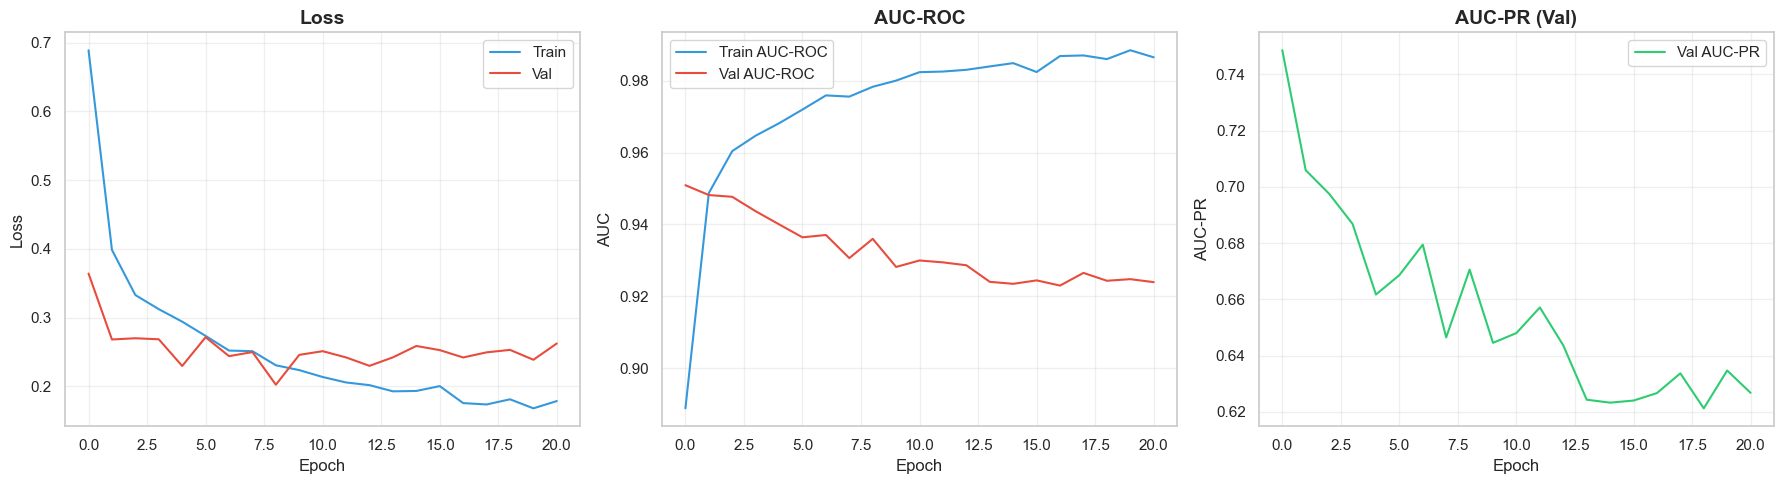

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(hist['tl'], label='Train', color='#3498db')
axes[0].plot(hist['vl'], label='Val', color='#e74c3c')
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist['ta'], label='Train AUC-ROC', color='#3498db')
axes[1].plot(hist['va'], label='Val AUC-ROC', color='#e74c3c')
axes[1].set_title('AUC-ROC', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(hist['vp'], label='Val AUC-PR', color='#2ecc71')
axes[2].set_title('AUC-PR (Val)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC-PR')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Evaluation on Validation Set

In [40]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
_, val_auc_roc, val_auc_pr, val_preds, val_labels = evaluate_model(model, val_loader)

print(f'Val AUC-ROC: {val_auc_roc:.4f}')
print(f'Val AUC-PR:  {val_auc_pr:.4f}')

Val AUC-ROC: 0.9509
Val AUC-PR:  0.7486


Optimal threshold: 0.76
Best F1: 0.6718


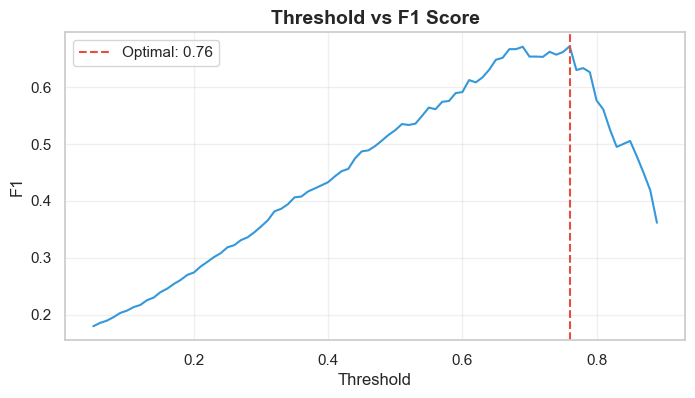

In [41]:
# Optimal threshold via F1
thresholds = np.arange(0.05, 0.90, 0.01)
f1s = [f1_score(val_labels, (val_preds >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1s)]

print(f'Optimal threshold: {best_thresh:.2f}')
print(f'Best F1: {max(f1s):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1s, color='#3498db')
plt.axvline(x=best_thresh, color='#e74c3c', ls='--', label=f'Optimal: {best_thresh:.2f}')
plt.title('Threshold vs F1 Score', fontsize=14, fontweight='bold')
plt.xlabel('Threshold'); plt.ylabel('F1')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [42]:
# Final metrics at optimal threshold
val_binary = (val_preds >= best_thresh).astype(int)

print('='*60)
print('FINAL VALIDATION RESULTS')
print('='*60)
print(f'Threshold: {best_thresh:.2f}')
print(f'AUC-ROC:   {val_auc_roc:.4f}')
print(f'AUC-PR:    {val_auc_pr:.4f}')
print(f'F1:        {f1_score(val_labels, val_binary):.4f}')
print(f'Precision: {precision_score(val_labels, val_binary):.4f}')
print(f'Recall:    {recall_score(val_labels, val_binary):.4f}')
print(f'\n{classification_report(val_labels, val_binary, target_names=["Not Readmitted", "Readmitted"])}')

FINAL VALIDATION RESULTS
Threshold: 0.76
AUC-ROC:   0.9509
AUC-PR:    0.7486
F1:        0.6718
Precision: 0.6984
Recall:    0.6471

                precision    recall  f1-score   support

Not Readmitted       0.97      0.97      0.97       692
    Readmitted       0.70      0.65      0.67        68

      accuracy                           0.94       760
     macro avg       0.83      0.81      0.82       760
  weighted avg       0.94      0.94      0.94       760



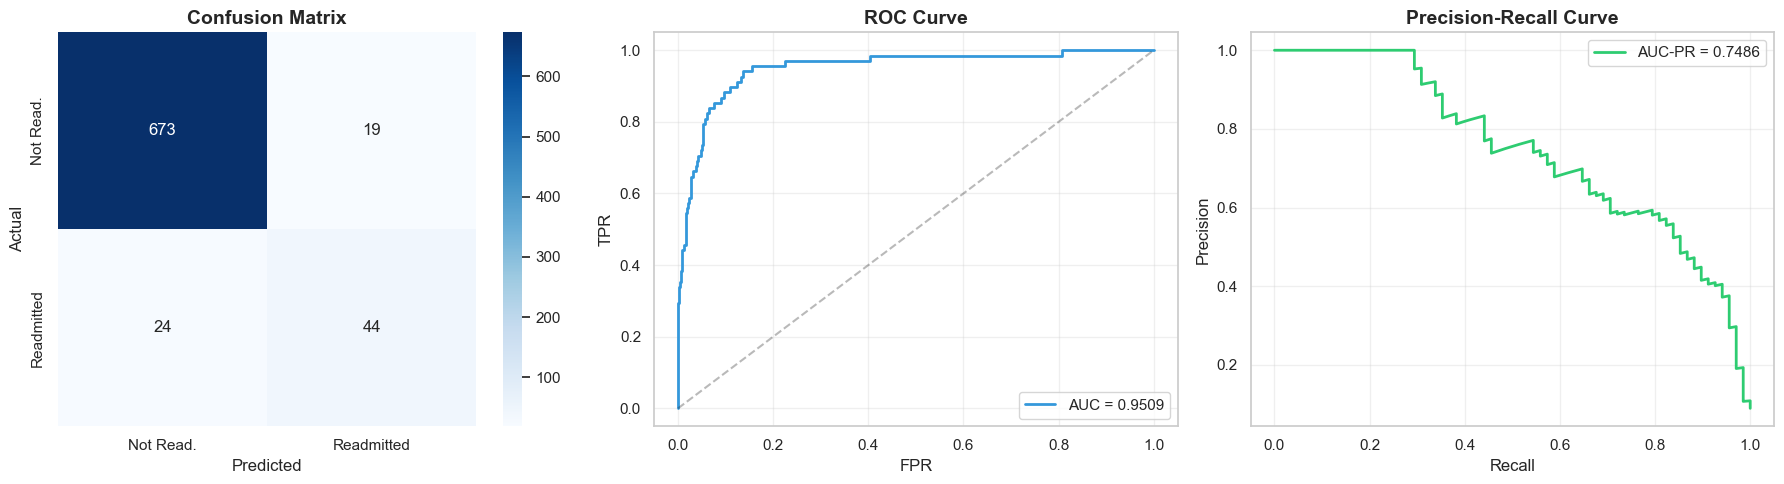

In [43]:
# Confusion Matrix, ROC, PR curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(val_labels, val_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Read.', 'Readmitted'],
            yticklabels=['Not Read.', 'Readmitted'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(val_labels, val_preds)
axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {val_auc_roc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.3)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

prec_vals, rec_vals, _ = precision_recall_curve(val_labels, val_preds)
axes[2].plot(rec_vals, prec_vals, color='#2ecc71', lw=2, label=f'AUC-PR = {val_auc_pr:.4f}')
axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Generate Test Predictions

In [44]:
model.eval()
with torch.no_grad():
    test_probs = model(X_test_t).numpy()

test_binary = (test_probs >= best_thresh).astype(int)

print(f'Test predictions: {len(test_binary)} samples')
print(f'Predicted positive: {test_binary.sum()} ({test_binary.mean()*100:.1f}%)')
print(f'Predicted negative: {(1-test_binary).sum()} ({(1-test_binary.mean())*100:.1f}%)')

results = pd.DataFrame({
    'readmitted_30d_prob': test_probs,
    'readmitted_30d_pred': test_binary
})
results.to_csv('test_predictions.csv', index=False)
print('\n✅ Saved to test_predictions.csv')

Test predictions: 950 samples
Predicted positive: 65 (6.8%)
Predicted negative: 885 (93.2%)

✅ Saved to test_predictions.csv


## 13. Summary

### Data Used
- **train_df.csv** (3,800 rows) — preprocessed by solution_1.ipynb
- **test_df.csv** (950 rows) — required completion of same pipeline

### Preprocessing Completed Here
1. Feature-engineered test_df's `admission_date` → month/day/weekday
2. Created `glucose_missing` indicator for test_df
3. Imputed NaN (age, glucose) using train medians
4. Encoded `gender` (binary), `insurance_type` (one-hot), `discharge_day_of_week` (one-hot)
5. StandardScaler on numeric features (fit on train only)

### Class Imbalance Mitigation
- **SMOTE** on training split (minority → 50% of majority)
- **Class-weighted BCE loss** during training
- **Threshold tuning** post-training (optimized for F1)

### Model
- 4-layer PyTorch feedforward network (128→64→32→16→1)
- BatchNorm + Dropout for regularization
- Adam optimizer + ReduceLROnPlateau scheduler
- Early stopping on validation AUC-ROC

### Evaluation
- AUC-ROC, AUC-PR, F1, Precision, Recall
- ⚠️ Accuracy NOT used as primary metric (due to 91%/9% imbalance)